# XGBoost WTI Crude Oil Baseline

**Target**: `YF_Price_Crude Oil (WTI)` — next-day prediction using 10-day lookback  
**Features**: All 46 columns + cyclic time features + rolling averages (3/5/10 day)  
**Train**: 2015-01-01 to 2024-12-31 | **Test**: 2025-01-01 to 2025-12-31  
**Evaluation**: Autoregressive 10-day forecast, MSPE metric

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from calendar import monthrange
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

pd.set_option("display.max_columns", 60)

# Load data
df = pd.read_csv("/kaggle/input/datasets/zygong1994/finance-world-model-dataset/combined_commodity_data.csv", parse_dates=["date"], index_col="date")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
df.head(3)

Shape: (4118, 46)
Date range: 2014-12-20 00:00:00 to 2026-03-29 00:00:00


,YF_Price_Gold,YF_Price_Silver,YF_Price_Crude Oil (WTI),YF_Price_Crude Oil (Brent),YF_Price_Natural Gas,YF_Price_Copper,YF_Price_Iron Ore,YF_Price_Lithium,YF_Price_Wheat,YF_Price_Soybean,YF_State_VXD(Dow Volatility Index),YF_State_VXN(Nasdaq Volatility Index),YF_State_GVZ(Gold Volatility Index),YF_State_EVZ(Energy Volatility Index),YF_State_MSCI World Index,YF_State_MSCI All Country Index,YF_State_Nikkei 225,YF_State_EURO STOXX 50,YF_State_Shanghai Composite,YF_State_Hang Seng Index,FRED_DGS10,FRED_T10YIE,FRED_DTWEXBGS,FRED_INDPRO,FRED_DFF,FRED_SP500,FRED_DJIA,FRED_NASDAQCOM,FRED_VIXCLS,FRED_OVXCLS,FRED_GDPC1,FRED_A191RL1Q225SBEA,FRED_RSAFS,FRED_CPIAUCSL,FRED_CPILFESL,FRED_PCEPI,FRED_PCEPILFE,FRED_PPIACO,FRED_UNRATE,FRED_PAYEMS,FRED_ICSA,FRED_DEXCHUS,EIA_Crude Inventory (US),EIA_Strategic Petroleum Reserve,EIA_Natural Gas Stock,EIA_US Crude Production
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-12-20,1179.699951,15.649,55.259998,60.110001,3.144,2.9035,20.592468,19.356659,625.75,1038.25,14.3,16.559999,20.26,9.63,58.89711,47.696217,17635.140625,3154.909912,3127.445068,23408.570312,2.17,1.7,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,18666.621,3.6,428208.0,234.747,239.811,96.654,96.214,192.0,5.7,140568.0,276000.0,6.2213,1043942.0,690963.0,3220.0,9121.0
2014-12-21,1179.699951,15.649,55.259998,60.110001,3.144,2.9035,20.592468,19.356659,625.75,1038.25,14.3,16.559999,20.26,9.63,58.89711,47.696217,17635.140625,3154.909912,3127.445068,23408.570312,2.17,1.7,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,18666.621,3.6,428208.0,234.747,239.811,96.654,96.214,192.0,5.7,140568.0,276000.0,6.2213,1043942.0,690963.0,3220.0,9121.0
2014-12-22,1179.699951,15.649,55.259998,60.110001,3.144,2.9035,20.592468,19.356659,625.75,1038.25,14.3,16.559999,20.26,9.63,58.89711,47.696217,17635.140625,3154.909912,3127.445068,23408.570312,2.17,1.7,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,18666.621,3.6,428208.0,234.747,239.811,96.654,96.214,192.0,5.7,140568.0,276000.0,6.2213,1043942.0,690963.0,3220.0,9121.0


## Feature Engineering

In [2]:
TARGET = "YF_Price_Crude Oil (WTI)"
LOOKBACK = 10
FORECAST_HORIZON = 10
raw_cols = df.columns.tolist()
print(f"Raw feature columns: {len(raw_cols)}")

# --- Rolling window averages (3, 5, 10 days) ---
for window in [3, 5, 10]:
    rolling = df[raw_cols].rolling(window=window, min_periods=1).mean()
    rolling.columns = [f"{c}_roll{window}" for c in raw_cols]
    df = pd.concat([df, rolling], axis=1)

print(f"After rolling features: {df.shape}")

# --- Cyclic time features ---
dow = df.index.dayofweek  # 0=Monday
dom = df.index.day
month = df.index.month
days_in_month = df.index.to_series().apply(lambda d: monthrange(d.year, d.month)[1])

df["time_dow_sin"] = np.sin(2 * np.pi * dow / 7)
df["time_dow_cos"] = np.cos(2 * np.pi * dow / 7)
df["time_dom_sin"] = np.sin(2 * np.pi * (dom - 1) / days_in_month)
df["time_dom_cos"] = np.cos(2 * np.pi * (dom - 1) / days_in_month)
df["time_month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
df["time_month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)

time_cols = [c for c in df.columns if c.startswith("time_")]
all_feature_cols = raw_cols + [c for c in df.columns if "_roll" in c]  # excludes time (added separately)

print(f"Total columns in df: {df.shape[1]}")
print(f"Feature cols (raw + rolling): {len(all_feature_cols)}")
print(f"Time cols: {len(time_cols)}")
df.head(3)

Raw feature columns: 46
After rolling features: (4118, 184)
Total columns in df: 190
Feature cols (raw + rolling): 184
Time cols: 6


,YF_Price_Gold,YF_Price_Silver,YF_Price_Crude Oil (WTI),YF_Price_Crude Oil (Brent),YF_Price_Natural Gas,YF_Price_Copper,YF_Price_Iron Ore,YF_Price_Lithium,YF_Price_Wheat,YF_Price_Soybean,YF_State_VXD(Dow Volatility Index),YF_State_VXN(Nasdaq Volatility Index),YF_State_GVZ(Gold Volatility Index),YF_State_EVZ(Energy Volatility Index),YF_State_MSCI World Index,YF_State_MSCI All Country Index,YF_State_Nikkei 225,YF_State_EURO STOXX 50,YF_State_Shanghai Composite,YF_State_Hang Seng Index,FRED_DGS10,FRED_T10YIE,FRED_DTWEXBGS,FRED_INDPRO,FRED_DFF,FRED_SP500,FRED_DJIA,FRED_NASDAQCOM,FRED_VIXCLS,FRED_OVXCLS,...,FRED_DTWEXBGS_roll10,FRED_INDPRO_roll10,FRED_DFF_roll10,FRED_SP500_roll10,FRED_DJIA_roll10,FRED_NASDAQCOM_roll10,FRED_VIXCLS_roll10,FRED_OVXCLS_roll10,FRED_GDPC1_roll10,FRED_A191RL1Q225SBEA_roll10,FRED_RSAFS_roll10,FRED_CPIAUCSL_roll10,FRED_CPILFESL_roll10,FRED_PCEPI_roll10,FRED_PCEPILFE_roll10,FRED_PPIACO_roll10,FRED_UNRATE_roll10,FRED_PAYEMS_roll10,FRED_ICSA_roll10,FRED_DEXCHUS_roll10,EIA_Crude Inventory (US)_roll10,EIA_Strategic Petroleum Reserve_roll10,EIA_Natural Gas Stock_roll10,EIA_US Crude Production_roll10,time_dow_sin,time_dow_cos,time_dom_sin,time_dom_cos,time_month_sin,time_month_cos
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-12-20,1179.699951,15.649,55.259998,60.110001,3.144,2.9035,20.592468,19.356659,625.75,1038.25,14.3,16.559999,20.26,9.63,58.89711,47.696217,17635.140625,3154.909912,3127.445068,23408.570312,2.17,1.7,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,...,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,18666.621,3.6,428208.0,234.747,239.811,96.654,96.214,192.0,5.7,140568.0,276000.0,6.2213,1043942.0,690963.0,3220.0,9121.0,-0.974928,-0.222521,-0.651372,-0.758758,-0.5,0.866025
2014-12-21,1179.699951,15.649,55.259998,60.110001,3.144,2.9035,20.592468,19.356659,625.75,1038.25,14.3,16.559999,20.26,9.63,58.89711,47.696217,17635.140625,3154.909912,3127.445068,23408.570312,2.17,1.7,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,...,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,18666.621,3.6,428208.0,234.747,239.811,96.654,96.214,192.0,5.7,140568.0,276000.0,6.2213,1043942.0,690963.0,3220.0,9121.0,-0.781831,0.623490,-0.790776,-0.612106,-0.5,0.866025
2014-12-22,1179.699951,15.649,55.259998,60.110001,3.144,2.9035,20.592468,19.356659,625.75,1038.25,14.3,16.559999,20.26,9.63,58.89711,47.696217,17635.140625,3154.909912,3127.445068,23408.570312,2.17,1.7,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,...,101.9942,102.8905,0.13,2037.05,17535.39,4781.42,15.25,54.82,18666.621,3.6,428208.0,234.747,239.811,96.654,96.214,192.0,5.7,140568.0,276000.0,6.2213,1043942.0,690963.0,3220.0,9121.0,0.000000,1.000000,-0.897805,-0.440394,-0.5,0.866025


## Build Lookback Windows

For each target day `t`, flatten the previous 10 days of all features into a single row.  
Rolling averages are taken at `t-1` only. Time features are for day `t`.

In [3]:
def build_lookback_features(df, raw_cols, all_feature_cols, time_cols, lookback=10):
    """Build feature matrix with 10-day lookback on raw cols + rolling at t-1 + time at t."""
    rolling_cols = [c for c in all_feature_cols if "_roll" in c]
    
    feature_names = []
    # Raw lookback feature names
    for lag in range(1, lookback + 1):
        for c in raw_cols:
            feature_names.append(f"{c}_lag{lag}")
    # Rolling at t-1
    for c in rolling_cols:
        feature_names.append(f"{c}_at_t1")
    # Time features
    feature_names.extend(time_cols)
    
    n = len(df)
    X_rows = []
    y_vals = []
    dates = []
    
    raw_arr = df[raw_cols].values
    roll_arr = df[rolling_cols].values
    time_arr = df[time_cols].values
    target_arr = df[TARGET].values
    idx = df.index
    
    for t in range(lookback, n):
        # Raw lookback: t-1, t-2, ..., t-lookback
        raw_flat = raw_arr[t - lookback:t][::-1].flatten()  # most recent first
        # Rolling at t-1
        roll_at_t1 = roll_arr[t - 1]
        # Time at t
        time_at_t = time_arr[t]
        
        row = np.concatenate([raw_flat, roll_at_t1, time_at_t])
        X_rows.append(row)
        y_vals.append(target_arr[t])
        dates.append(idx[t])
    
    X = np.array(X_rows)
    y = np.array(y_vals)
    return X, y, dates, feature_names

X_all, y_all, dates_all, feature_names = build_lookback_features(
    df, raw_cols, all_feature_cols, time_cols, LOOKBACK
)
print(f"Feature matrix: {X_all.shape}")
print(f"Feature names: {len(feature_names)}")
print(f"Date range: {dates_all[0]} to {dates_all[-1]}")

Feature matrix: (4108, 604)
Feature names: 604
Date range: 2014-12-30 00:00:00 to 2026-03-29 00:00:00


## Train / Validation / Test Split

In [4]:
dates_arr = pd.DatetimeIndex(dates_all)

train_mask = (dates_arr >= "2015-01-01") & (dates_arr < "2024-01-01")
val_mask = (dates_arr >= "2024-01-01") & (dates_arr < "2025-01-01")
test_mask = (dates_arr >= "2025-01-01") & (dates_arr < "2026-01-01")

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]
dates_test = dates_arr[test_mask]

print(f"Train: {X_train.shape[0]} samples ({dates_arr[train_mask][0]} to {dates_arr[train_mask][-1]})")
print(f"Val:   {X_val.shape[0]} samples ({dates_arr[val_mask][0]} to {dates_arr[val_mask][-1]})")
print(f"Test:  {X_test.shape[0]} samples ({dates_arr[test_mask][0]} to {dates_arr[test_mask][-1]})")

Train: 3287 samples (2015-01-01 00:00:00 to 2023-12-31 00:00:00)
Val:   366 samples (2024-01-01 00:00:00 to 2024-12-31 00:00:00)
Test:  365 samples (2025-01-01 00:00:00 to 2025-12-31 00:00:00)


## Train XGBoost

In [5]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best val RMSE: {model.best_score:.4f}")

[0]	validation_0-rmse:15.35708
[50]	validation_0-rmse:2.92614
[100]	validation_0-rmse:2.02871
[150]	validation_0-rmse:1.85600
[200]	validation_0-rmse:1.84347
[208]	validation_0-rmse:1.85038

Best iteration: 158
Best val RMSE: 1.8134


## Single-Step Sanity Check

Single-step test RMSE: $1.30
Single-step test MAPE: 1.444%


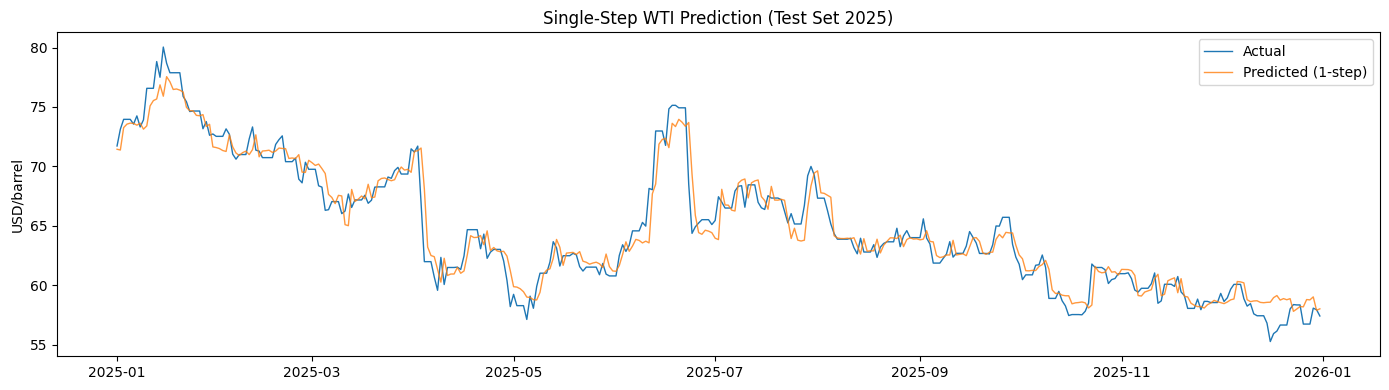

In [6]:
y_pred_single = model.predict(X_test)
mse_single = mean_squared_error(y_test, y_pred_single)
mape_single = np.mean(np.abs((y_pred_single - y_test) / y_test)) * 100

print(f"Single-step test RMSE: ${mse_single**0.5:.2f}")
print(f"Single-step test MAPE: {mape_single:.3f}%")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_test, y_test, label="Actual", linewidth=1)
ax.plot(dates_test, y_pred_single, label="Predicted (1-step)", linewidth=1, alpha=0.8)
ax.set_title("Single-Step WTI Prediction (Test Set 2025)")
ax.set_ylabel("USD/barrel")
ax.legend()
plt.tight_layout()
plt.show()

## Autoregressive 10-Day Forecast

For each forecast origin, predict 10 days ahead autoregressively:
- WTI price: use predicted values for future steps
- All other features: hold at last-known observed values
- Rolling averages: recomputed on the updated buffer

In [7]:
def build_single_feature_row(buffer_raw, buffer_rolling_cols, target_date, raw_cols, rolling_cols, time_cols_list, lookback=10):
    """
    Build a single feature row from a buffer of raw data.
    
    buffer_raw: DataFrame with raw_cols, at least `lookback` rows, most recent at the end.
    target_date: the date we're predicting for (used for time features).
    """
    # Raw lookback: last `lookback` rows, reversed (most recent first)
    raw_flat = buffer_raw[raw_cols].values[-lookback:][::-1].flatten()
    
    # Rolling averages at t-1 (last row of buffer)
    roll_vals = []
    for window in [3, 5, 10]:
        rolled = buffer_raw[raw_cols].rolling(window=window, min_periods=1).mean().iloc[-1].values
        roll_vals.append(rolled)
    roll_flat = np.concatenate(roll_vals)
    
    # Time features for target_date
    dow = target_date.dayofweek
    dom = target_date.day
    month = target_date.month
    dim = monthrange(target_date.year, target_date.month)[1]
    
    time_feats = np.array([
        np.sin(2 * np.pi * dow / 7),
        np.cos(2 * np.pi * dow / 7),
        np.sin(2 * np.pi * (dom - 1) / dim),
        np.cos(2 * np.pi * (dom - 1) / dim),
        np.sin(2 * np.pi * (month - 1) / 12),
        np.cos(2 * np.pi * (month - 1) / 12),
    ])
    
    return np.concatenate([raw_flat, roll_flat, time_feats]).reshape(1, -1)


# Get the full raw dataframe (without rolling/time cols) for buffer manipulation
df_raw = df[raw_cols].copy()
target_col_idx = raw_cols.index(TARGET)

# Find test period indices in df_raw
test_start = pd.Timestamp("2025-01-01")
test_end = pd.Timestamp("2025-12-31")
test_dates_in_df = df_raw.loc[test_start:test_end].index

# Non-overlapping 10-day forecast windows
forecast_results = []  # list of (origin_date, [10 predictions], [10 actuals], [10 dates])

origin_idx = 0
while origin_idx + FORECAST_HORIZON <= len(test_dates_in_df):
    forecast_dates = test_dates_in_df[origin_idx:origin_idx + FORECAST_HORIZON]
    origin_date = forecast_dates[0]
    
    # Get buffer: 10 days before the first forecast date
    origin_pos = df_raw.index.get_loc(origin_date)
    buffer = df_raw.iloc[origin_pos - LOOKBACK:origin_pos].copy()
    
    preds = []
    actuals = []
    
    for step in range(FORECAST_HORIZON):
        target_date = forecast_dates[step]
        actual_val = df_raw.loc[target_date, TARGET]
        
        # Build features from current buffer
        row = build_single_feature_row(buffer, None, target_date, raw_cols, None, time_cols, LOOKBACK)
        pred = model.predict(row)[0]
        
        preds.append(pred)
        actuals.append(actual_val)
        
        # Update buffer: append a new row with predicted WTI, last-known for others
        new_row = buffer.iloc[-1].copy()  # last-known values for all features
        new_row[TARGET] = pred  # substitute predicted WTI
        new_row.name = target_date
        buffer = pd.concat([buffer, new_row.to_frame().T])
        buffer = buffer.iloc[-LOOKBACK:]  # keep only last `lookback` rows
    
    forecast_results.append({
        "origin": origin_date,
        "dates": list(forecast_dates),
        "preds": preds,
        "actuals": actuals,
    })
    origin_idx += FORECAST_HORIZON

print(f"Total forecast windows: {len(forecast_results)}")
print(f"First origin: {forecast_results[0]['origin']}")
print(f"Last origin: {forecast_results[-1]['origin']}")

Total forecast windows: 36
First origin: 2025-01-01 00:00:00
Last origin: 2025-12-17 00:00:00


## Metrics

**MSPE** = `(1/10) * Σ |(pred - truth) / truth|²` per window, then averaged across windows.

In [8]:
# Per-window MSPE
window_mspe = []
for r in forecast_results:
    preds = np.array(r["preds"])
    actuals = np.array(r["actuals"])
    spe = ((preds - actuals) / actuals) ** 2
    mspe = spe.mean()  # 1/10 * sum
    window_mspe.append(mspe)

window_mspe = np.array(window_mspe)
print(f"Average MSPE across {len(window_mspe)} windows: {window_mspe.mean():.6f}")
print(f"Average RMSPE: {np.sqrt(window_mspe.mean()) * 100:.2f}%")
print(f"Min window MSPE: {window_mspe.min():.6f} | Max: {window_mspe.max():.6f}")

# Per-step breakdown (average across all windows for each horizon step)
per_step_spe = np.zeros(FORECAST_HORIZON)
for r in forecast_results:
    preds = np.array(r["preds"])
    actuals = np.array(r["actuals"])
    per_step_spe += ((preds - actuals) / actuals) ** 2
per_step_spe /= len(forecast_results)

print("\nPer-step MSPE breakdown:")
print("-" * 35)
for step in range(FORECAST_HORIZON):
    print(f"  Step {step+1:2d} (day +{step+1:2d}): MSPE={per_step_spe[step]:.6f}  RMSPE={np.sqrt(per_step_spe[step])*100:.2f}%")

Average MSPE across 36 windows: 0.002213
Average RMSPE: 4.70%
Min window MSPE: 0.000143 | Max: 0.019302

Per-step MSPE breakdown:
-----------------------------------
  Step  1 (day + 1): MSPE=0.000323  RMSPE=1.80%
  Step  2 (day + 2): MSPE=0.000463  RMSPE=2.15%
  Step  3 (day + 3): MSPE=0.000983  RMSPE=3.13%
  Step  4 (day + 4): MSPE=0.001967  RMSPE=4.44%
  Step  5 (day + 5): MSPE=0.002594  RMSPE=5.09%
  Step  6 (day + 6): MSPE=0.002399  RMSPE=4.90%
  Step  7 (day + 7): MSPE=0.002749  RMSPE=5.24%
  Step  8 (day + 8): MSPE=0.003256  RMSPE=5.71%
  Step  9 (day + 9): MSPE=0.003288  RMSPE=5.73%
  Step 10 (day +10): MSPE=0.004111  RMSPE=6.41%


## Visualization

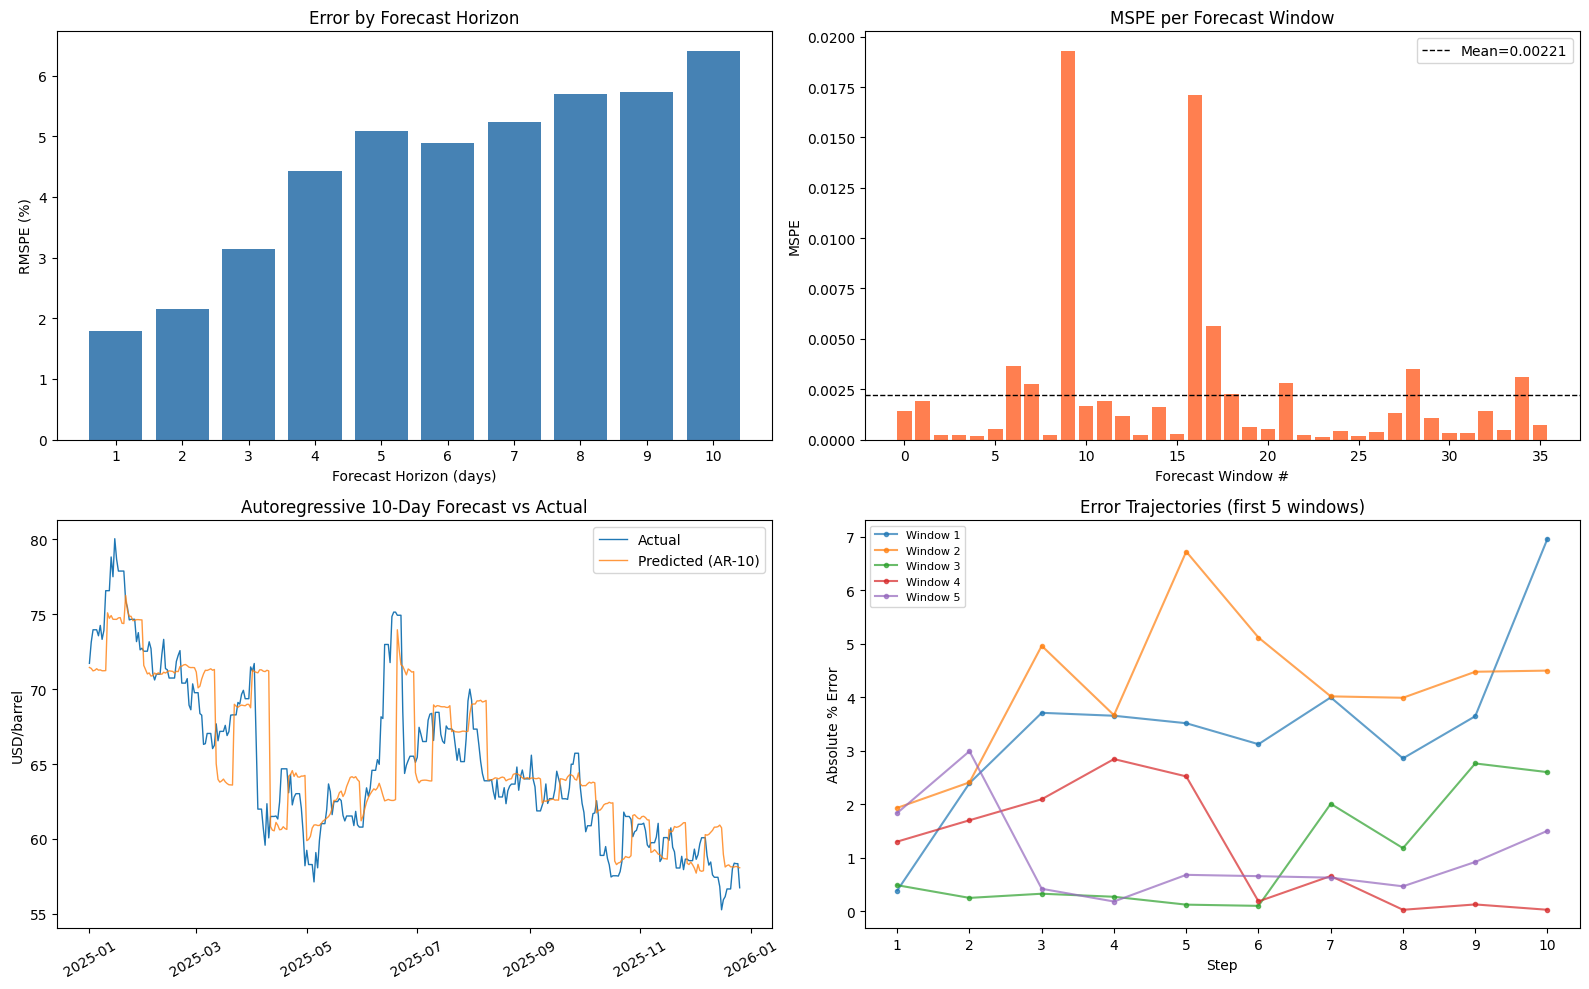

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Per-step RMSPE
ax = axes[0, 0]
ax.bar(range(1, FORECAST_HORIZON + 1), np.sqrt(per_step_spe) * 100, color="steelblue")
ax.set_xlabel("Forecast Horizon (days)")
ax.set_ylabel("RMSPE (%)")
ax.set_title("Error by Forecast Horizon")
ax.set_xticks(range(1, FORECAST_HORIZON + 1))

# 2. Per-window MSPE
ax = axes[0, 1]
origins = [r["origin"] for r in forecast_results]
ax.bar(range(len(window_mspe)), window_mspe, color="coral")
ax.set_xlabel("Forecast Window #")
ax.set_ylabel("MSPE")
ax.set_title("MSPE per Forecast Window")
ax.axhline(window_mspe.mean(), color="black", linestyle="--", linewidth=1, label=f"Mean={window_mspe.mean():.5f}")
ax.legend()

# 3. Predicted vs Actual (all windows concatenated)
ax = axes[1, 0]
all_dates_flat = []
all_preds_flat = []
all_actuals_flat = []
for r in forecast_results:
    all_dates_flat.extend(r["dates"])
    all_preds_flat.extend(r["preds"])
    all_actuals_flat.extend(r["actuals"])
ax.plot(all_dates_flat, all_actuals_flat, label="Actual", linewidth=1)
ax.plot(all_dates_flat, all_preds_flat, label="Predicted (AR-10)", linewidth=1, alpha=0.8)
ax.set_ylabel("USD/barrel")
ax.set_title("Autoregressive 10-Day Forecast vs Actual")
ax.legend()
ax.tick_params(axis="x", rotation=30)

# 4. Sample forecast windows (first 3)
ax = axes[1, 1]
for i, r in enumerate(forecast_results[:5]):
    days = list(range(1, FORECAST_HORIZON + 1))
    pct_err = np.abs((np.array(r["preds"]) - np.array(r["actuals"])) / np.array(r["actuals"])) * 100
    ax.plot(days, pct_err, marker="o", markersize=3, label=f"Window {i+1}", alpha=0.7)
ax.set_xlabel("Step")
ax.set_ylabel("Absolute % Error")
ax.set_title("Error Trajectories (first 5 windows)")
ax.legend(fontsize=8)
ax.set_xticks(range(1, FORECAST_HORIZON + 1))

plt.tight_layout()
plt.show()

## Feature Importance (Top 20)

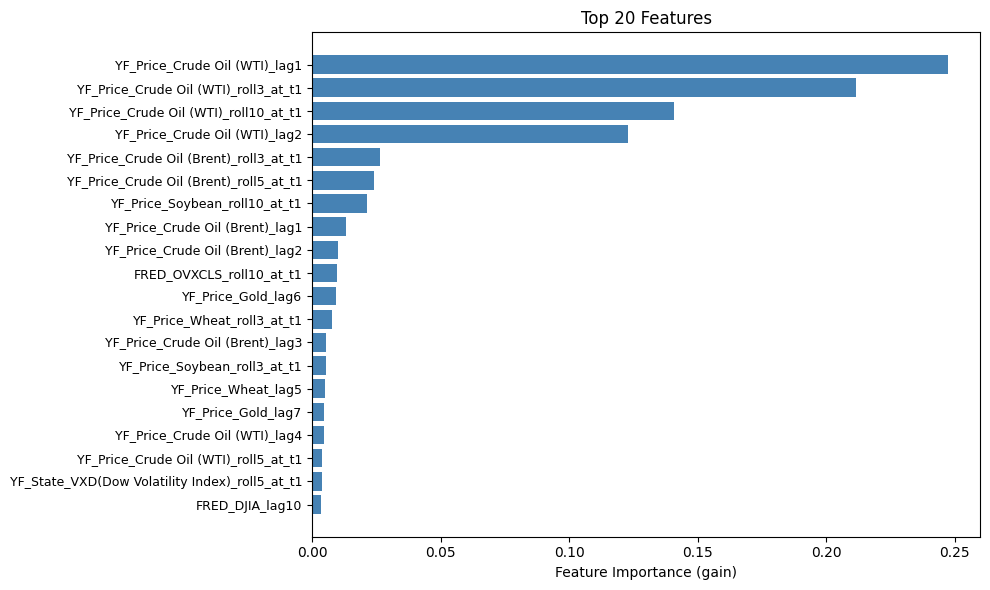

In [10]:
importances = model.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_k), importances[top_idx][::-1], color="steelblue")
ax.set_yticks(range(top_k))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title(f"Top {top_k} Features")
plt.tight_layout()
plt.show()